# LLM-Proto: Build Your Own LLM From Scratch

This notebook validates the full pipeline end-to-end on a **tiny model** (~30M params).  
Designed to run in Google Colab (T4 GPU) or locally.

**Pipeline:**
1. Install dependencies
2. Train BPE tokenizer on sample data
3. Tokenize & save data as binary shards
4. Build model & inspect architecture
5. Run a mini training loop
6. Generate text samples
7. Visualize model internals

---

## 1. Install Dependencies

Installs all required Python packages via `pip`.  
Key libraries:
- **`torch`** — PyTorch, the deep-learning framework powering our model and training loop.
- **`tokenizers`** — HuggingFace's Rust-backed BPE tokenizer (10–100× faster than pure Python).
- **`datasets`** — HuggingFace hub for streaming large text corpora without downloading them fully.
- **`wandb`** — Weights & Biases for experiment tracking (loss curves, generated samples, visualizations).
- **`google-api-python-client` / `google-auth`** — Google Drive API for checkpoint backup & resume.

> **Tip:** On Colab the GPU runtime already has PyTorch pre-installed, but we force `>=2.1.0` for `torch.compile` and Flash Attention support.

In [1]:
# ── Cell 1: Install Dependencies ──
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg in [
    "torch>=2.1.0", "tokenizers", "datasets", "wandb", "safetensors",
    "matplotlib", "seaborn", "scikit-learn", "numpy", "pyyaml", "tqdm",
    "google-api-python-client>=2.100.0", "google-auth>=2.23.0",
]:
    install(pkg)

print("All dependencies installed!")

All dependencies installed!


## 2. Imports, Setup & Settings

This cell does three things:

1. **Adds the project root to `sys.path`** so Python can find the `src/` package.  
   On Colab it also clones the repo if you haven't already.

2. **Imports all modules** from `src/` — config, model, tokenizer, and utilities.

3. **Defines user-configurable settings** in one place at the top:
   - `MODEL_SIZE` — which preset to use (`"tiny"` ≈ 30M params up to `"large"` ≈ 1.4B).
   - `ENABLE_GDRIVE` / `GDRIVE_FOLDER_ID` — enables checkpoint backup to Google Drive.
   - `RESUME_FROM` — set to `"latest"` or `"step_N"` to resume training from a saved checkpoint.
   - `N_STEPS` — number of mini-training steps (keep small for notebook validation).

> **Edit the Settings block** to configure your run before executing subsequent cells.

In [2]:
# ── Cell 2: Imports, Setup & Settings ──
import os, sys, torch, math, time
import numpy as np
from contextlib import nullcontext

# Add project root to path so we can import src/
if os.path.basename(os.getcwd()) != "LLM-Proto":
    if "google.colab" in sys.modules:
        !git clone -b unlimited-data https://github.com/VlSePr/LLM-Proto
        os.chdir("LLM-Proto")

from src.config import ModelConfig, TrainConfig, MODEL_CONFIGS, get_model_config
from src.model import TransformerLM
from src.tokenizer import LLMTokenizer
from src.utils import (
    detect_environment, get_device, get_dtype, set_seed,
    get_lr, save_checkpoint, load_checkpoint,
)

# ─────────────────────────────────────────
# Settings  (edit these to configure the run)
# ─────────────────────────────────────────
MODEL_SIZE      = "large"            # "tiny", "small", "medium", "base", "large"
TOKENIZER_PATH  = "tokenizer_data"
DATA_DIR        = "data"
DATA_CONFIG     = "configs/data.yaml"
CKPT_DIR        = "checkpoints"
N_STEPS         = 30000              # mini-training steps (for notebook validation)

# Google Drive integration
ENABLE_GDRIVE       = True
GDRIVE_FOLDER_ID    = "LLM"            # Colab: folder name under MyDrive; Local: Drive folder ID from URL
GDRIVE_CREDENTIALS  = ""            # service-account .json path (local only, ignored on Colab)
GDRIVE_DATA_DIR     = ""            # Path to training data on Drive, e.g. "my-training-data"
                                    # In Colab this becomes /content/drive/MyDrive/<GDRIVE_DATA_DIR>
GDRIVE_TOKENIZER_FOLDER_ID = ""    # Dedicated Drive folder for tokenizer backup
                                    # Colab: folder name under MyDrive; Local: real Drive folder ID
RESUME_FROM         = "Large"            # "" = fresh start, "latest", "best", or "step_N"

# ─────────────────────────────────────────

env = detect_environment()
device = get_device()
dtype = get_dtype()
print(f"Environment: {env}")
print(f"Device: {device}")
print(f"Dtype: {dtype}")
print(f"PyTorch: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Cloning into 'LLM-Proto'...
remote: Enumerating objects: 122, done.
remote: Counting objects: 100% (122/122), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 122 (delta 68), reused 94 (delta 40), pack-reused 0 (from 0)
Receiving objects: 100% (122/122), 502.76 KiB | 4.83 MiB/s, done.
Resolving deltas: 100% (68/68), done.
Environment: colab
Device: cuda
Dtype: torch.bfloat16
PyTorch: 2.10.0+cu128
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM: 102.0 GB


## 2b. Google Drive & Checkpoint Resume

Handles two optional features that depend on the Settings above:

**Google Drive Mount (Colab)**  
If `ENABLE_GDRIVE = True`, this cell mounts your Google Drive so that:
- Checkpoints can be backed up to / restored from the `GDRIVE_FOLDER_ID` folder.
- Training data stored on Drive (`GDRIVE_DATA_DIR`) becomes accessible as a local path.

On non-Colab environments (vast.ai, local), it uses the Drive REST API via service-account credentials instead of filesystem mounting.

**Checkpoint Resume**  
If `RESUME_FROM` is set (e.g., `"latest"`, `"best"`, `"step_5000"`):
1. Builds the model and optimizer.
2. Downloads the checkpoint from Drive if it's not found locally.
3. Restores model weights, optimizer state (momentum/variance), and RNG states for **bit-exact reproducibility**.
4. Sets `start_step` so the training loop picks up where it left off.

> **Skip this cell** if you're starting from scratch (`RESUME_FROM = ""`).

In [3]:
# ── Cell 2b: Connect to Google Drive & Resume Checkpoint ──
# Mounts Google Drive early so it's available for:
#   - Training data  (GDRIVE_DATA_DIR → data sources in data.yaml)
#   - Checkpoint backup & resume (GDRIVE_FOLDER_ID + RESUME_FROM)
# Also handles checkpoint resume — downloading from Drive if needed.

start_step = 0    # default: train from scratch
optimizer = None   # will be created in the training cell if not restored here

# ── 1. Mount / verify Google Drive ──
if ENABLE_GDRIVE:
    is_colab = "google.colab" in sys.modules

    if is_colab:
        from google.colab import drive
        MOUNT_POINT = "/content/drive"
        if not os.path.ismount(MOUNT_POINT):
            drive.mount(MOUNT_POINT)
            print(f"Google Drive mounted at {MOUNT_POINT}")
        else:
            print(f"Google Drive already mounted at {MOUNT_POINT}")

        # Show checkpoint folder status
        if GDRIVE_FOLDER_ID:
            ckpt_drive_path = os.path.join(MOUNT_POINT, "MyDrive", GDRIVE_FOLDER_ID)
            os.makedirs(ckpt_drive_path, exist_ok=True)
            n_files = len([f for f in os.listdir(ckpt_drive_path) if f.endswith(".pt")])
            print(f"Checkpoint folder: {ckpt_drive_path} ({n_files} .pt files)")

        # Show training data folder status
        if GDRIVE_DATA_DIR:
            data_drive_path = os.path.join(MOUNT_POINT, "MyDrive", GDRIVE_DATA_DIR)
            if os.path.isdir(data_drive_path):
                n_txt = len([f for f in os.listdir(data_drive_path) if f.endswith(".txt")])
                n_jsonl = len([f for f in os.listdir(data_drive_path) if f.endswith(".jsonl")])
                print(f"Training data folder: {data_drive_path}")
                print(f"  .txt files:   {n_txt}")
                print(f"  .jsonl files: {n_jsonl}")
            else:
                print(f"Warning: GDRIVE_DATA_DIR not found at {data_drive_path}")
    else:
        if GDRIVE_CREDENTIALS and os.path.isfile(GDRIVE_CREDENTIALS):
            print(f"Google Drive API credentials: {GDRIVE_CREDENTIALS}")
        elif GDRIVE_CREDENTIALS:
            print(f"Warning: credentials file not found: {GDRIVE_CREDENTIALS}")
        else:
            print("Google Drive API mode (will use Application Default Credentials)")

    print("Google Drive integration: ENABLED")
else:
    print("Google Drive integration: DISABLED")

# ── 2. Resume from checkpoint (local or Google Drive) ──
if RESUME_FROM:
    print(f"\nResuming from '{RESUME_FROM}'...")

    gdrive_kw = {}
    if ENABLE_GDRIVE and GDRIVE_FOLDER_ID:
        gdrive_kw = dict(gdrive_folder_id=GDRIVE_FOLDER_ID,
                         gdrive_credentials_path=GDRIVE_CREDENTIALS)

    model_config = get_model_config(MODEL_SIZE)
    model = TransformerLM(model_config).to(device)

    # Create optimizer so we can restore its state (momentum, etc.)
    optimizer = torch.optim.AdamW(model.parameters(), lr=6e-4, weight_decay=0.1,
                                   betas=(0.9, 0.95), eps=1e-8)

    ckpt = load_checkpoint(CKPT_DIR, RESUME_FROM, model, optimizer=optimizer,
                           device=device, **gdrive_kw)
    start_step = ckpt["step"] + 1
    print(f"Restored step {ckpt['step']} (loss={ckpt['loss']:.4f}). "
          f"Training will resume from step {start_step}.")
else:
    print("\nFresh start (RESUME_FROM is empty).")

Mounted at /content/drive
Google Drive mounted at /content/drive
Checkpoint folder: /content/drive/MyDrive/LLM (3 .pt files)
Google Drive integration: ENABLED

Resuming from 'Large'...
Checkpoint not found locally, downloading 'Large.pt' from Google Drive...
  → Downloaded to checkpoints/Large.pt
Loading checkpoint from checkpoints/Large.pt...
Resumed from step 9999 (loss=3.8664)
Restored step 9999 (loss=3.8664). Training will resume from step 10000.


## 3. Inspect Model Configurations

Prints all five built-in presets (`tiny` → `large`) side by side so you can compare:
- **dim** — hidden dimension (width of each layer's representation).
- **layers** — number of Transformer blocks stacked.
- **heads / kv_heads** — query heads vs. key-value heads (GQA reduces memory when kv_heads < heads).
- **ffn** — feed-forward inner dimension (SwiGLU, so 3 weight matrices instead of 2).
- **seq** — maximum context length.
- **~params** — estimated total parameters (embedding + Transformer layers + LM head).

In [4]:
# ── Cell 3: Inspect All Model Configs ──
print("Available model configurations:\n")
for name, cfg in MODEL_CONFIGS.items():
    est = cfg.param_count_estimate()
    print(f"  {name:8s} | dim={cfg.dim:5d} | layers={cfg.n_layers:2d} | "
          f"heads={cfg.n_heads:2d}/{cfg.n_kv_heads} | ffn={cfg.ffn_dim:5d} | "
          f"seq={cfg.max_seq_len:4d} | ~{est/1e6:.0f}M params")

Available model configurations:

  tiny     | dim=  512 | layers= 6 | heads= 8/4 | ffn= 1536 | seq=2048 | ~34M params
  small    | dim=  768 | layers=12 | heads=12/4 | ffn= 2048 | seq=2048 | ~93M params
  medium   | dim= 1024 | layers=24 | heads=16/4 | ffn= 2816 | seq=2048 | ~278M params
  base     | dim= 1280 | layers=24 | heads=20/4 | ffn= 3584 | seq=2048 | ~426M params
  large    | dim= 2048 | layers=32 | heads=32/8 | ffn= 5632 | seq=4096 | ~1374M params


## 4. Build Model & Verify Forward Pass

Instantiates the Transformer model on the selected device and runs a **sanity check**:

1. Feeds random token IDs through the model.
2. Prints the output logits shape — should be `(batch, seq_len, vocab_size)`.
3. Compares the initial loss to **ln(vocab_size)** ≈ 10.37.  
   An untrained model assigns roughly equal probability to every token, so its cross-entropy loss should be close to `ln(V)`. If it's wildly different, something is wrong with the architecture.

This cell also calls `model.summary()` which shows layer counts, total parameters, and memory estimate.

In [5]:
# ── Cell 4: Build Model & Verify ──
set_seed(42)

if "model" not in globals() or not isinstance(model, TransformerLM):
    model_config = get_model_config(MODEL_SIZE)
    model = TransformerLM(model_config).to(device)
else:
    model_config = get_model_config(MODEL_SIZE)
    print("Reusing resumed model from Cell 2b")

print(model.summary())

# Verify forward pass with random data
dummy_ids = torch.randint(0, model_config.vocab_size, (2, 128), device=device)
dummy_targets = torch.randint(0, model_config.vocab_size, (2, 128), device=device)

with torch.no_grad():
    out = model(dummy_ids, targets=dummy_targets)

print(f"\nForward pass OK!")
print(f"  Logits shape: {out['logits'].shape}")
print(f"  Loss: {out['loss'].item():.4f}")
print(f"  Expected initial loss (ln(vocab)): {np.log(model_config.vocab_size):.4f}")

Reusing resumed model from Cell 2b
TransformerLM Summary
  Layers: 32
  Hidden dim: 2048
  Attention heads: 32 (KV heads: 8)
  Head dim: 64
  FFN dim: 5632
  Vocab size: 32000
  Max seq len: 4096
  Tie embeddings: True
  Total params: 1,508,509,696 (1508.5M)
  Trainable params: 1,508,509,696 (1508.5M)

Forward pass OK!
  Logits shape: torch.Size([2, 128, 32000])
  Loss: 12.3217
  Expected initial loss (ln(vocab)): 10.3735


## 5. Test Generation (Untrained Model)

Runs `model.generate()` with random weights to verify the autoregressive loop works.  
**Expected output: complete gibberish** — the model hasn't learned anything yet.

Under the hood, `generate()` uses **KV-cache**: the full prompt is processed once (prefill), then each new token only attends to the cached keys/values plus its own query, making generation O(T) per step instead of O(T²).

In [6]:
# ── Cell 5: Test Generation (random weights — gibberish expected) ──
prompt_ids = torch.tensor([[1, 100, 200, 300]], dtype=torch.long, device=device)  # Dummy prompt
generated = model.generate(prompt_ids, max_new_tokens=20, temperature=0.8, top_k=50)
print(f"Generated token IDs: {generated[0].tolist()}")
print(f"(Gibberish expected — model is untrained)")

Generated token IDs: [1, 100, 200, 300, 18, 1006, 353, 435, 737, 266, 1788, 285, 266, 1044, 16, 541, 266, 1788, 285, 266, 2220, 335, 497, 947]
(Gibberish expected — model is untrained)


## 6. Load or Train the BPE Tokenizer

The tokenizer converts raw text into integer token IDs that the model processes.

**Resolution order:**
1. **Local file** (`tokenizer_data/tokenizer.json`) — fastest, already trained.
2. **Google Drive** — downloads a previously trained tokenizer from your Drive folder.
3. **Train from scratch** — reads text samples from `configs/data.yaml` sources and trains a new BPE tokenizer using HuggingFace's `tokenizers` library (Rust-backed, very fast).

**Key design choices:**
- **BPE (Byte Pair Encoding)** with `byte_fallback=True` — guarantees zero UNK tokens; any byte sequence can be represented, even emoji or binary data.
- **vocab_size = 32,000** — a sweet spot balancing compression ratio (fewer tokens per sentence = faster training) vs. embedding table size.
- **Special tokens**: `<|bos|>`, `<|eos|>`, `<|pad|>`, `<|im_start|>`, `<|im_end|>` reserved at positions 0–4 for sequence boundaries and future chat formatting.

After loading/training, a quick encode→decode round-trip verifies the tokenizer works correctly.

In [7]:
# ── Cell 6: Load or Train Tokenizer ──
# Priority: (1) local path → (2) Google Drive → (3) train from scratch.
# After training, the tokenizer is automatically uploaded to Google Drive.

import yaml
from src.data import iter_texts_from_sources

tok_file = os.path.join(TOKENIZER_PATH, "tokenizer.json")
tok = None

# 1. Try local
if os.path.exists(tok_file):
    tok = LLMTokenizer(TOKENIZER_PATH)
    print(f"Tokenizer loaded from local path (vocab_size={tok.vocab_size})")

# 2. Try Google Drive
if tok is None and ENABLE_GDRIVE and GDRIVE_TOKENIZER_FOLDER_ID:
    print("Tokenizer not found locally, checking Google Drive...")
    try:
        from src.gdrive import download_from_gdrive
        download_from_gdrive("tokenizer.json", GDRIVE_TOKENIZER_FOLDER_ID,
                             TOKENIZER_PATH, credentials_path=GDRIVE_CREDENTIALS)
        tok = LLMTokenizer(TOKENIZER_PATH)
        print(f"  Downloaded from Google Drive (vocab_size={tok.vocab_size})")
    except FileNotFoundError:
        print("  Not found on Google Drive either.")
    except Exception as e:
        print(f"  Google Drive download failed: {e}")

# 3. Train from scratch
if tok is None:
    print("Training tokenizer from scratch...")
    with open(DATA_CONFIG, "r") as f:
        cfg = yaml.safe_load(f)

    tok_cfg = cfg["tokenizer"]
    sources = cfg.get("sources", [])
    num_samples = tok_cfg.get("num_samples", 50_000)
    vocab_size = tok_cfg.get("vocab_size", 32_000)

    def text_iterator():
        count = 0
        for text in iter_texts_from_sources(sources):
            if count >= num_samples:
                break
            if text and len(text) > 50:
                yield text
                count += 1
        print(f"  Used {count:,} text samples for tokenizer training")

    tok = LLMTokenizer.train(
        texts=text_iterator(),
        vocab_size=vocab_size,
        save_path=TOKENIZER_PATH,
    )
    print(f"  Trained tokenizer (vocab_size={tok.vocab_size})")

    # Upload to Google Drive
    if ENABLE_GDRIVE and GDRIVE_TOKENIZER_FOLDER_ID:
        from src.gdrive import upload_to_gdrive
        upload_to_gdrive(tok_file, GDRIVE_TOKENIZER_FOLDER_ID,
                         credentials_path=GDRIVE_CREDENTIALS)
        print("  Uploaded tokenizer to Google Drive")

# Quick test
test_text = "Hello, world! This is a test of the tokenizer."
ids = tok.encode(test_text, add_bos=True, add_eos=True)
decoded = tok.decode(ids)
print(f"\nTokenizer ready (vocab_size={tok.vocab_size})")
print(f"  Input:   {test_text}")
print(f"  Tokens:  {ids[:20]}{'...' if len(ids) > 20 else ''}")
print(f"  Decoded: {decoded}")

Tokenizer loaded from local path (vocab_size=32000)

Tokenizer ready (vocab_size=32000)
  Input:   Hello, world! This is a test of the tokenizer.
  Tokens:  [0, 44, 13724, 16, 913, 5, 662, 315, 262, 1103, 285, 266, 19447, 6017, 18, 1]
  Decoded: Hello, world! This is a test of the tokenizer.


## 7. Tokenize Data → Binary Shards

Converts raw text into training-ready binary files:

1. Reads text from all sources defined in `configs/data.yaml` (HuggingFace streaming datasets + local `.txt`/`.jsonl` files).
2. Tokenizes each document and **packs** them end-to-end (no padding waste — every token is used for learning).
3. Saves as **`uint16` binary shards** (`train_0000.bin`, `train_0001.bin`, …) with a configurable shard size.

**Why binary shards?**
- **Memory-mapped I/O** (`np.memmap`) — the DataLoader reads directly from disk without loading entire files into RAM. This lets you train on datasets much larger than your available memory.
- **`uint16`** — each token takes only 2 bytes (vs. 4 for int32), halving storage. Works because vocab_size ≤ 65,535.
- **Sharding** — enables parallel loading and makes it easy to add more data later.

> If `.bin` files already exist, this cell skips tokenization. Delete them to re-process.

In [8]:
# ── Cell 7: Tokenize Data → Binary Shards ──
# Uses configs/data.yaml to pull from HuggingFace + local custom data.
# Edit data.yaml to add/remove sources and tune processing params.

from src.data import tokenize_and_save

if os.path.exists(os.path.join(DATA_DIR, "train_0000.bin")):
    print(f"Tokenized data already exists in {DATA_DIR}, skipping.")
    print("Delete the .bin files to re-tokenize.")
else:
    print(f"Tokenizing data (config: {DATA_CONFIG})...")
    tokenize_and_save(
        tokenizer_path=TOKENIZER_PATH,
        output_dir=DATA_DIR,
        config_path=DATA_CONFIG,
    )
    print("Data tokenization complete!")

Tokenized data already exists in data, skipping.
Delete the .bin files to re-tokenize.


## 8. Verify the DataLoader

Quick sanity check: loads one batch from the binary shards and prints:
- **Shape** — should be `(batch_size, max_seq_len)` for both inputs and targets.
- **Sample tokens** — raw integer IDs from the first sequence.
- **Decoded text** — the first ~200 characters, so you can visually verify the data looks like real text.

The DataLoader uses `pin_memory=True` for faster CPU→GPU transfer and `drop_last=True` to avoid a ragged final batch (which would break gradient accumulation).

In [9]:
# ── Cell 8: Verify DataLoader ──
from src.data import create_dataloader

train_loader = create_dataloader(DATA_DIR, model_config.max_seq_len, batch_size=4, split="train", num_workers=0)

batch = next(iter(train_loader))
input_ids, targets = batch

print(f"Batch input_ids shape: {input_ids.shape}")
print(f"Batch targets shape:   {targets.shape}")
print(f"Sample tokens: {input_ids[0, :20].tolist()}")
print(f"Decoded: {tok.decode(input_ids[0, :50].tolist())[:200]}")

Created train DataLoader: 24,414 samples, 100,000,000 tokens
Batch input_ids shape: torch.Size([4, 4096])
Batch targets shape:   torch.Size([4, 4096])
Sample tokens: [630, 2305, 18, 1060, 266, 3895, 448, 315, 985, 332, 470, 288, 448, 8523, 285, 1611, 266, 19663, 18, 203]
Decoded:  some understanding. For the moment this is important for us in this notion of God the Creator.
And then in this relatedness between the Creator and things created, once more I would like to underline


## 9. Mini Training Loop

Runs a short training loop (`N_STEPS` steps) to validate the entire pipeline works end-to-end.  
**This is NOT production training** — just enough to confirm the loss decreases.

**What's happening at each step:**

| Component | Details |
|-----------|---------|
| **Optimizer** | AdamW with weight decay=0.1 and β₂=0.95 (lower than default 0.999 — stabilizes training with large, noisy batches per GPT-3/LLaMA convention) |
| **Learning Rate** | Cosine decay with linear warmup: ramps from 0 → 6e-4 over 10 steps, then smoothly decays to 6e-5. Formula: `lr = min_lr + (peak - min) × 0.5 × (1 + cos(π × progress))` |
| **Mixed Precision** | `autocast` runs matmuls in fp16/bf16 for ~2× speed; `GradScaler` prevents underflow (fp16 only — bf16 has the same range as fp32 so no scaler needed) |
| **Gradient Clipping** | `clip_grad_norm_(1.0)` caps the global gradient L2 norm, preventing catastrophic updates from noisy batches |
| **`set_to_none=True`** | Zeros gradients by setting them to `None` instead of filling with 0s — saves a memset operation |

If the final loss is lower than the initial loss, the pipeline is working correctly.

In [10]:
# ── Cell 9: Mini Training Loop (Quick Validation) ──
# Runs a small training loop (~N_STEPS steps) to verify everything works.
# NOT for production — just to confirm loss decreases.
# If Cell 2b resumed from a checkpoint, we reuse model, optimizer and start_step.

set_seed(42)

# Fresh model only if Cell 2b didn't already create one
if "model" not in globals() or not isinstance(model, TransformerLM):
    model_config = get_model_config(MODEL_SIZE)
    model = TransformerLM(model_config).to(device)

if "start_step" not in globals():
    start_step = 0

# Recreate optimizer only if missing
if "optimizer" not in globals() or optimizer is None:
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=6e-4,
        weight_decay=0.1,
        betas=(0.9, 0.95),
        eps=1e-8
    )

# Reuse optimizer from Cell 2b (with restored momentum) or create a fresh one
if optimizer is None:
    optimizer = torch.optim.AdamW(model.parameters(), lr=6e-4, weight_decay=0.1,
                                   betas=(0.9, 0.95), eps=1e-8)


import gc, torch

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

print("CUDA memory cleaned")

# DataLoader
train_loader = create_dataloader(DATA_DIR, model_config.max_seq_len, batch_size=4,
                                  split="train", num_workers=0)
train_iter = iter(train_loader)

# Mixed precision
use_amp = dtype in (torch.float16, torch.bfloat16) and device.type == "cuda"
amp_ctx = torch.amp.autocast(device_type="cuda", dtype=dtype) if use_amp else nullcontext()
scaler = torch.amp.GradScaler(enabled=(use_amp and dtype == torch.float16))

# Training
model.train()
losses = []

print(f"Mini training: {N_STEPS} steps (starting from {start_step}), batch=4, seq={model_config.max_seq_len}")
print(f"AMP: {use_amp}, dtype: {dtype}\n")

t0 = time.time()
for step in range(start_step, N_STEPS):
    try:
        input_ids, targets = next(train_iter)
    except StopIteration:
        train_iter = iter(train_loader)
        input_ids, targets = next(train_iter)

    input_ids = input_ids.to(device)
    targets = targets.to(device)

    lr = get_lr(step, warmup_steps=10, max_steps=N_STEPS, peak_lr=6e-4, min_lr=6e-5)
    for pg in optimizer.param_groups:
        pg["lr"] = lr

    optimizer.zero_grad(set_to_none=True)
    with amp_ctx:
        out = model(input_ids, targets=targets)
        loss = out["loss"]

    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    scaler.step(optimizer)
    scaler.update()

    losses.append(loss.item())
    if step % 10 == 0:
        print(f"  step {step:3d} | loss {loss.item():.4f} | ppl {math.exp(min(loss.item(), 20)):.1f} | lr {lr:.2e}")

elapsed = time.time() - t0
print(f"\nDone! {len(losses)} steps in {elapsed:.1f}s")
print(f"Loss: {losses[0]:.4f} → {losses[-1]:.4f} (Δ = {losses[0] - losses[-1]:.4f})")
print(f"✓ Loss is decreasing — pipeline works!" if losses[-1] < losses[0] else "✗ Loss did not decrease — check for bugs")

CUDA memory cleaned
Created train DataLoader: 24,414 samples, 100,000,000 tokens
Mini training: 30000 steps (starting from 10000), batch=4, seq=4096
AMP: True, dtype: torch.bfloat16

  step 10000 | loss 3.9477 | ppl 51.8 | lr 4.65e-04
  step 10010 | loss 3.9276 | ppl 50.8 | lr 4.65e-04
  step 10020 | loss 4.0418 | ppl 56.9 | lr 4.65e-04
  step 10030 | loss 4.3616 | ppl 78.4 | lr 4.64e-04
  step 10040 | loss 4.1517 | ppl 63.5 | lr 4.64e-04
  step 10050 | loss 3.7905 | ppl 44.3 | lr 4.64e-04
  step 10060 | loss 4.4954 | ppl 89.6 | lr 4.64e-04
  step 10070 | loss 4.0549 | ppl 57.7 | lr 4.63e-04
  step 10080 | loss 3.9407 | ppl 51.5 | lr 4.63e-04
  step 10090 | loss 4.1467 | ppl 63.2 | lr 4.63e-04
  step 10100 | loss 3.8816 | ppl 48.5 | lr 4.63e-04
  step 10110 | loss 4.1277 | ppl 62.0 | lr 4.62e-04
  step 10120 | loss 4.0863 | ppl 59.5 | lr 4.62e-04
  step 10130 | loss 3.9971 | ppl 54.4 | lr 4.62e-04
  step 10140 | loss 4.1208 | ppl 61.6 | lr 4.62e-04
  step 10150 | loss 4.2176 | ppl 67.9

KeyboardInterrupt: 

## 10. Training Loss Curve

Plots the loss over the mini training run.  
A healthy curve should show a **steep initial drop** (the model quickly learns to predict common tokens) followed by a gradual decline.

If you see:
- **Flat line** — learning rate is too low, or the data is not reaching the model.
- **Spikes** — learning rate is too high, or a corrupted data batch.
- **Loss = ln(vocab)** (~10.37) and never drops — the model isn't learning at all (check data pipeline).

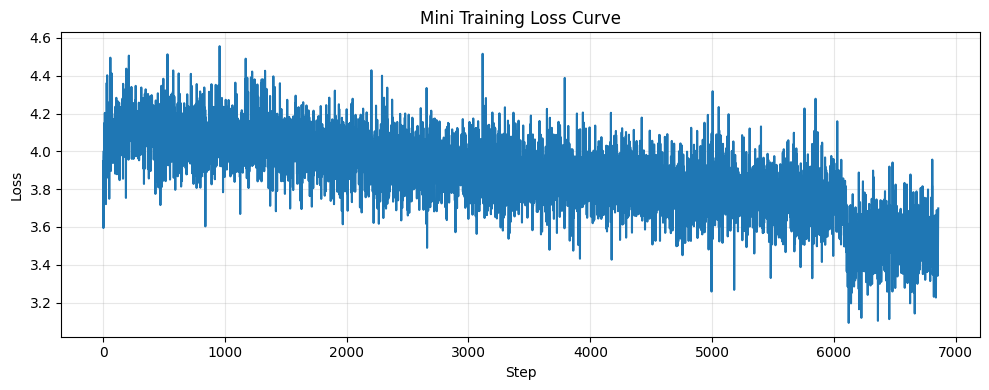

In [11]:
# ── Cell 10: Plot Training Loss ──
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(losses, linewidth=1.5)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Mini Training Loss Curve")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Generate Text After Training

Tests text generation with the (slightly) trained model.  
After just ~100 steps you'll see semi-random text, but it should be *less* random than the untrained output from Cell 5 — more English-like fragments, repeated common words, possibly some grammatical structure emerging.

**Sampling parameters** (configured in the code):
- **temperature = 0.8** — scales logits before softmax. Lower → more deterministic; higher → more creative.
- **top_k = 50** — only consider the top 50 most likely next tokens.
- **top_p = 0.9** — (nucleus sampling) only consider tokens whose cumulative probability ≤ 0.9.

In [12]:
# ── Cell 11: Generate Text After Mini Training ──
model.eval()

prompts = [
    "The meaning of life is",
    "Once upon a time",
    "In the year 2050",
]

for prompt in prompts:
    ids = tok.encode(prompt, add_bos=True)
    input_tensor = torch.tensor([ids], dtype=torch.long, device=device)
    output = model.generate(input_tensor, max_new_tokens=50, temperature=0.8, top_k=50)
    text = tok.decode(output[0].tolist())
    print(f"Prompt: {prompt}")
    print(f"Output: {text[:200]}")
    print("-" * 60)

Prompt: The meaning of life is
Output: The meaning of life is the beginning of a new era of life.
In our modern world, life has become increasingly difficult and daunting. We are constantly seeking to develop new ways of living, such as ea
------------------------------------------------------------
Prompt: Once upon a time
Output: Once upon a time,
and it is the time to go on to explore the mysteries.
This is a new book in the book "The Story of the Gods," which will be published by The
Rocky Mountain Press.
The book is a set
------------------------------------------------------------
Prompt: In the year 2050
Output: In the year 2050 is a long time of human history. This is true because we have not written a history of the universe. We can now say that this is the period where the universe began. But, until then, 
------------------------------------------------------------


## 12. Visualize Model Internals

Four diagnostic plots that reveal what the model has learned:

| Plot | What it shows | What to look for |
|------|---------------|------------------|
| **Weight Distributions** | Std of weights grouped by layer type | Should be roughly uniform (~0.02). Large outliers suggest initialization or gradient issues. |
| **Activation Stats** | Mean and std of layer outputs | Means should stay near 0 (RMSNorm keeps this stable); stds should be consistent across layers. |
| **Per-Token Loss** | Heatmap of cross-entropy loss for each token position | Function words ("the", "is") should be easy (low loss); content words hard (high loss). |
| **Attention Heatmap** | Which tokens each position attends to (layer 0, head 0) | Causal mask visible as upper triangle. Early layers often show local/diagonal attention; deeper layers show longer-range patterns. |

> These plots are automatically logged to WandB during full training runs (`src/visualize.py`).

Weight distributions:


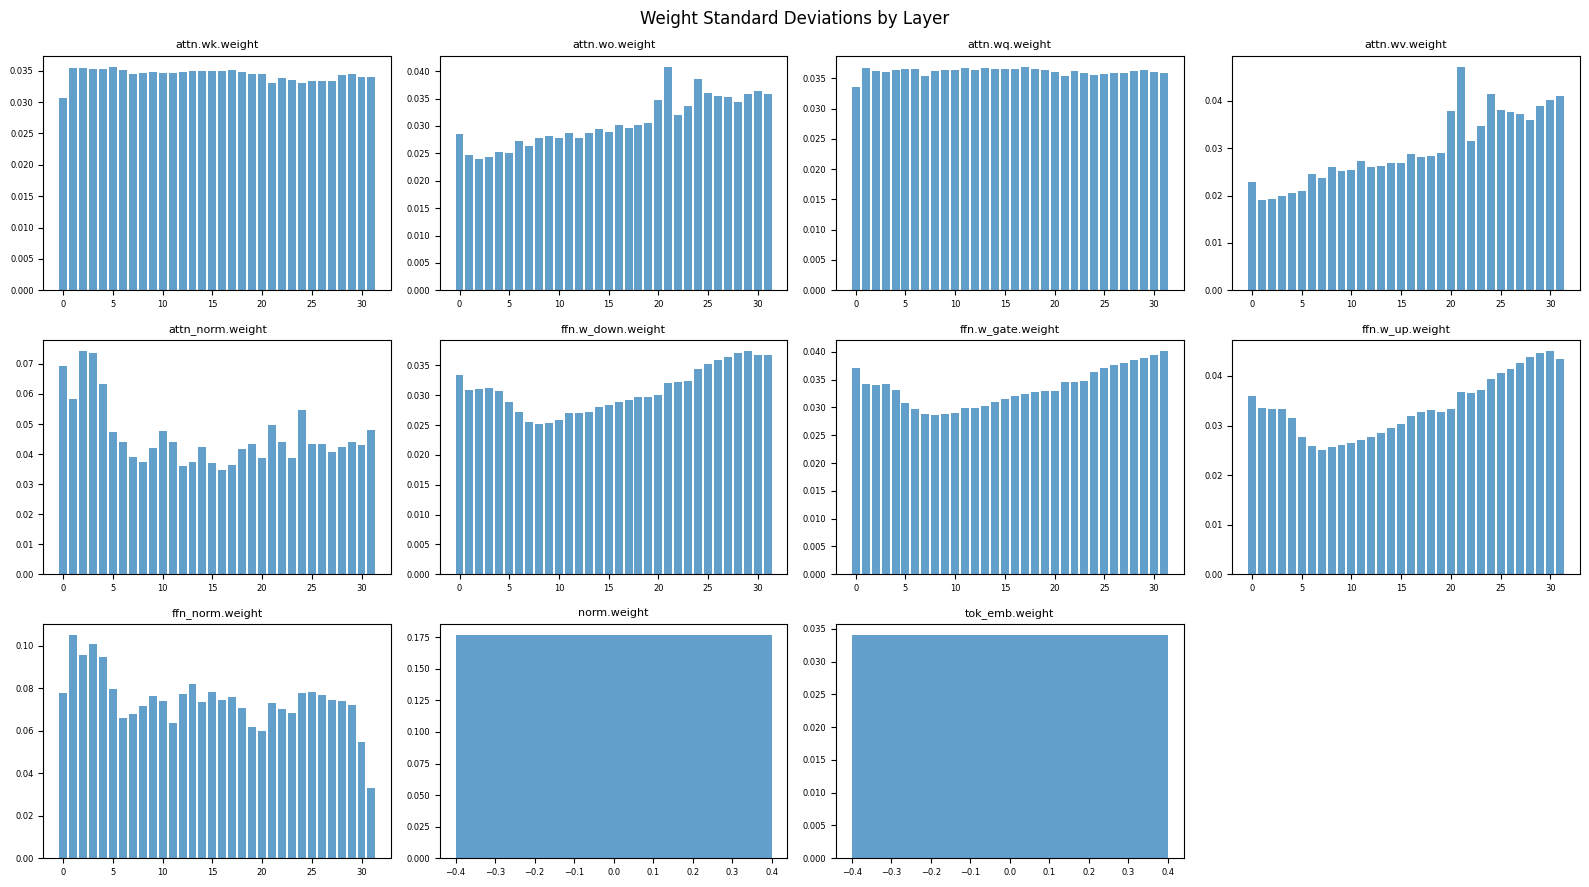


Activation stats:


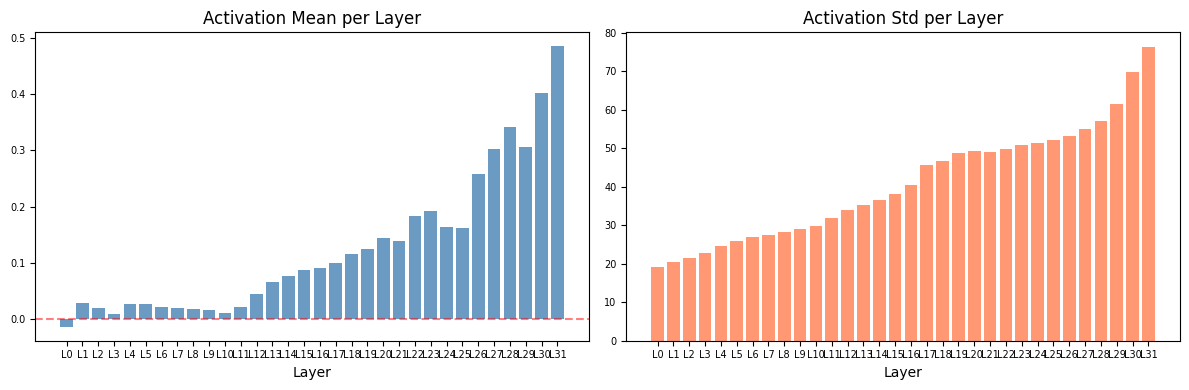


Per-token loss heatmap:


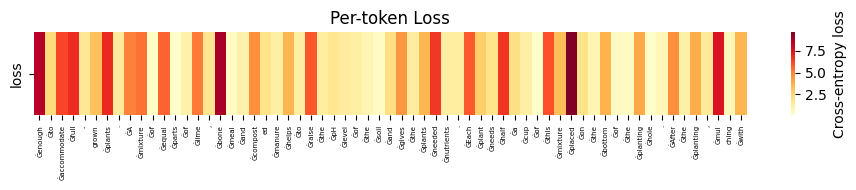


Attention heatmap (layer 0, head 0):


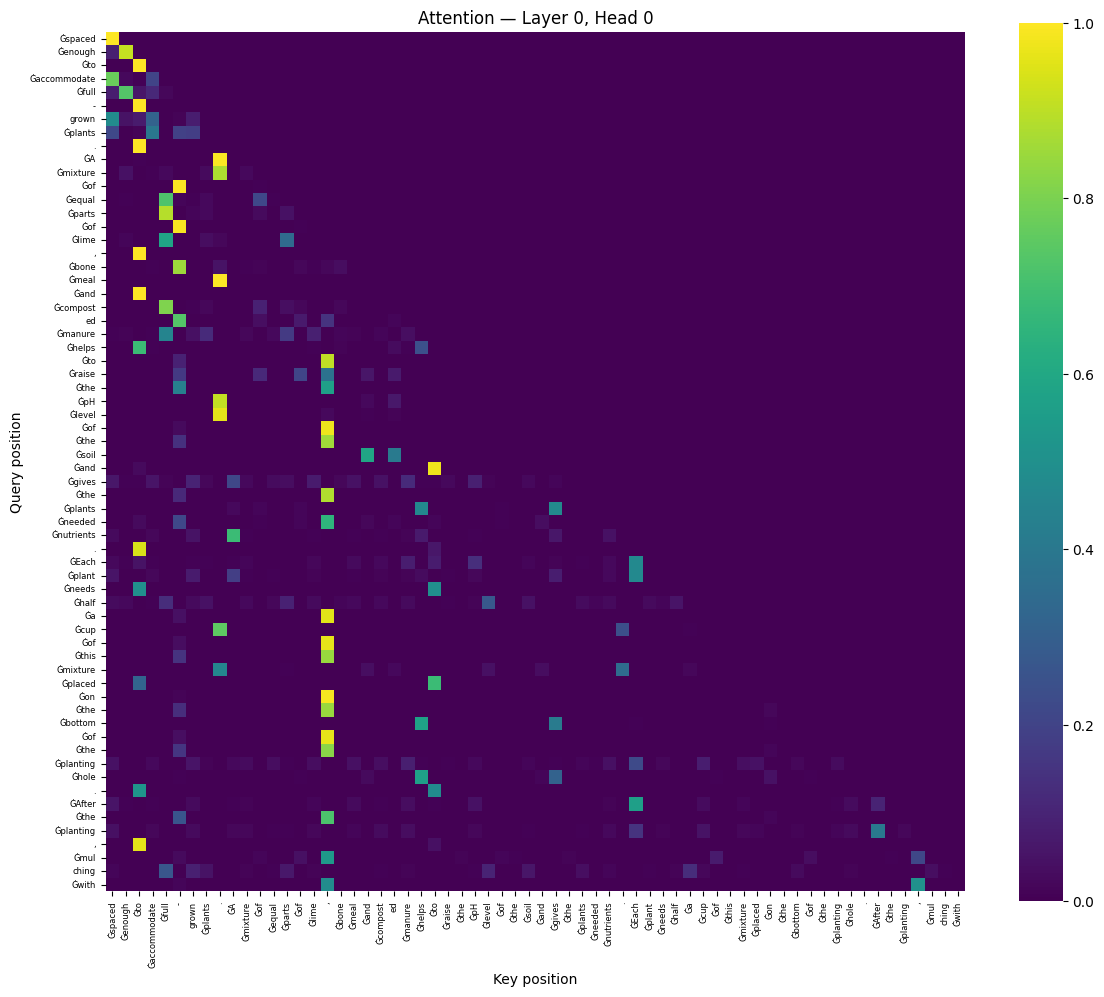

In [13]:
# ── Cell 12: Visualize Model Internals ──
from src.visualize import (
    plot_weight_distributions,
    plot_activation_stats,
    plot_token_loss_heatmap,
    plot_attention_heatmap,
)

# Grab a sample batch for activation / attention visualizations
sample_ids = next(iter(train_loader))[0][:1].to(device)

# 1. Weight distributions across layers
print("Weight distributions:")
fig = plot_weight_distributions(model)
plt.show()

# 2. Activation mean & std per layer
print("\nActivation stats:")
fig = plot_activation_stats(model, sample_ids)
plt.show()

# 3. Per-token loss heatmap
print("\nPer-token loss heatmap:")
fig = plot_token_loss_heatmap(model, sample_ids, tok, max_len=64)
plt.show()

# 4. Attention heatmap (layer 0, head 0)
print("\nAttention heatmap (layer 0, head 0):")
fig = plot_attention_heatmap(model, sample_ids, tok, layer_idx=0, head_idx=0, max_len=64)
plt.show()

## 13. Save & Load Checkpoint

Tests the full checkpoint round-trip:

1. **Saves** the model to `checkpoints/latest.pt` — includes model weights, optimizer state (momentum + variance buffers), RNG states (Python, NumPy, PyTorch CPU/CUDA), and config metadata.
2. **Loads** into a freshly instantiated model and verifies every parameter tensor matches exactly.

**Why save RNG states?** So that resumed training sees the *exact same* data order and dropout masks, producing bit-identical results regardless of where/when you resume.

**Why save optimizer state?** AdamW maintains per-parameter running averages (m and v). Without them, resuming would reset momentum, causing a temporary loss spike as the optimizer re-adapts.

In [14]:
# ── Cell 13: Save & Load Checkpoint Test ──
train_config = TrainConfig(use_wandb=False)

# Save (skip if checkpoint already exists at this step)
ckpt_path = os.path.join(CKPT_DIR, "latest.pt")
if not os.path.exists(ckpt_path):
    save_checkpoint(model, optimizer, step=N_STEPS - 1, loss=losses[-1],
                    model_config=model_config, train_config=train_config,
                    checkpoint_dir=CKPT_DIR)
    print(f"Checkpoint saved to {CKPT_DIR}/")
else:
    print(f"Checkpoint already exists at {ckpt_path}, skipping save.")

# Load into a fresh model
model2 = TransformerLM(model_config).to(device)
ckpt = load_checkpoint(CKPT_DIR, "latest", model2, device=device)
print(f"Loaded checkpoint from step {ckpt['step']}")

# Verify weights match
for (n1, p1), (n2, p2) in zip(model.named_parameters(), model2.named_parameters()):
    assert torch.equal(p1, p2), f"Mismatch at {n1}"
print("✓ Checkpoint save/load verified — weights match!")

Checkpoint saved to checkpoints/
Loading checkpoint from checkpoints/latest.pt...
Resumed from step 29999 (loss=3.6979)
Loaded checkpoint from step 29999
✓ Checkpoint save/load verified — weights match!


## 14. Upload Checkpoint to Google Drive (Optional)

Uploads the local `latest.pt` checkpoint to your Google Drive folder and lists all remote checkpoints.

- **Colab mode**: uses filesystem mount (`shutil.copy2`) — fast, no API overhead.
- **Local/vast.ai mode**: uses the Drive REST API v3 with **resumable uploads** — if the connection drops mid-transfer, the upload resumes from the last chunk instead of restarting.

> This cell is a **no-op** if `ENABLE_GDRIVE = False` in Cell 2.

In [15]:
# ── Cell 14: (Optional) Upload Checkpoint to Google Drive ──
# Uploads the latest checkpoint and lists what's already on Drive.
# Set ENABLE_GDRIVE = True in Cell 2 and fill in your folder ID.

if ENABLE_GDRIVE:
    from src.gdrive import upload_to_gdrive, list_remote_checkpoints

    # ── 1. Upload current checkpoint to Drive ──
    ckpt_path = os.path.join(CKPT_DIR, "latest.pt")
    if os.path.exists(ckpt_path):
        file_id = upload_to_gdrive(ckpt_path, GDRIVE_FOLDER_ID, GDRIVE_CREDENTIALS)
        print(f"Uploaded {ckpt_path} → Google Drive (id: {file_id})")
    else:
        print(f"No local checkpoint at {ckpt_path}, skipping upload.")

    # ── 2. List available remote checkpoints ──
    remote_files = list_remote_checkpoints(GDRIVE_FOLDER_ID, GDRIVE_CREDENTIALS)
    print(f"\nCheckpoints on Google Drive ({len(remote_files)}):")
    for f in remote_files:
        print(f"  {f['name']:20s}  {f['createdTime']}")
else:
    print("Google Drive upload skipped (ENABLE_GDRIVE = False in Cell 2)")

Uploaded checkpoints/latest.pt → Google Drive (id: /content/drive/MyDrive/LLM/latest.pt)

Checkpoints on Google Drive (3):
  medium.pt             1773226277.0
  Large-4.1.pt          1774211460.0
  latest.pt             1774211536.0
